For Week 11, include concepts such as density-based spatial clustering of applications with noise (DBSCAN), hierarchical agglomerative clustering (HAC), linkage methods in HAC, and dendrograms. Complete your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter


In [2]:
random_state = 42

## ECC

### Import Dataset

In [3]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [5]:
# Identify all float64 columns
float64_cols = df.select_dtypes(include=['float64']).columns

# Convert only those columns to float32
df[float64_cols] = df[float64_cols].astype('float32')

In [6]:
df.dtypes

Time      float32
V1        float32
V2        float32
V3        float32
V4        float32
V5        float32
V6        float32
V7        float32
V8        float32
V9        float32
V10       float32
V11       float32
V12       float32
V13       float32
V14       float32
V15       float32
V16       float32
V17       float32
V18       float32
V19       float32
V20       float32
V21       float32
V22       float32
V23       float32
V24       float32
V25       float32
V26       float32
V27       float32
V28       float32
Amount    float32
Class       int64
dtype: object

In [8]:
X = df.drop(columns='Class')
y = df['Class']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 284315, 1: 492})
Resampled dataset shape: Counter({0: 49200, 1: 492})


### Split Data

### Scaling

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### DBScan

In [12]:
min_samples = 2 * len(X.columns) # 2*D to avoid clustering marking sparse regions as valid clusters. With a value of 3 I found 1800 clusters
min_samples

60

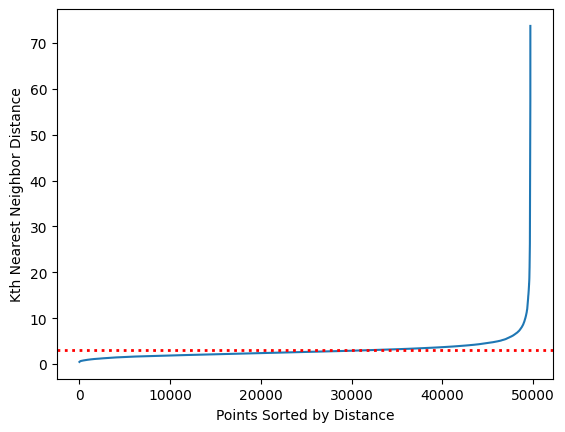

In [46]:
# 1. Set k to your min_samples value
k = min_samples

# 2. Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# 3. Sort distances by the k-th neighbor column (index k-1)
sorted_distances = np.sort(distances[:, k-1])

# 4. Plot to find the Epsilon elbow
plt.plot(sorted_distances)
plt.ylabel("Kth Nearest Neighbor Distance")
plt.xlabel("Points Sorted by Distance")
plt.axhline(y=3, linestyle=':', color='red', linewidth=2)
None

In [47]:
eps = 3 # Based on the curve, 3 looks to be where the elbow is

In [35]:
clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)

In [36]:
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 9393


In [37]:
# Convert X to pandas df for easier aggregation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns).copy()

In [39]:
# Combine cluster labels and target variable into a single summary DataFrame
summary_df = pd.DataFrame({"cluster": labels, "target": y_resampled})

In [40]:
# --- 3. Aggregate Cluster Statistics ---
cluster_stats = (
    summary_df.groupby("cluster")
    .agg(
        cluster_size=("target", "count"),
        positive_count=("target", "sum"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

In [41]:
# Global metrics for context
global_pos_rate = y.mean()
print(f"Total Data Points: {len(X_scaled_df)}")
print(f"Global Positive Rate: {global_pos_rate:.4f}")
print(
    f"Number of Clusters (excluding noise): {len(set(labels)) - (1 if -1 in labels else 0)}"
)

Total Data Points: 49692
Global Positive Rate: 0.0017
Number of Clusters (excluding noise): 3


In [42]:
# --- 4. Identify Target-Rich Clusters ---
# Sort by highest concentration of your positive target class
high_purity_clusters = cluster_stats.sort_values(
    by="positive_rate", ascending=False
).head(10)
print("\n--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---")
print(high_purity_clusters.to_string(index=False))


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
      -1          9393             449       0.047802
       1          2059               3       0.001457
       0         36099              40       0.001108
       2          2141               0       0.000000


In [43]:
# --- 5. Identify Popular Clusters ---
# Sort by size to find the largest groups (excluding noise cluster -1)
popular_clusters = (
    cluster_stats[cluster_stats["cluster"] != -1]
    .sort_values(by="cluster_size", ascending=False)
    .head(10)
)
print("\n--- TOP 10 LARGEST VALID CLUSTERS ---")
print(popular_clusters.to_string(index=False))


--- TOP 10 LARGEST VALID CLUSTERS ---
 cluster  cluster_size  positive_count  positive_rate
       0         36099              40       0.001108
       2          2141               0       0.000000
       1          2059               3       0.001457


In [44]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = popular_clusters.iloc[0]["cluster"]

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 0.0 ---
        Cluster Mean   Global Mean  Difference
Time        0.032836 -6.448414e-09    0.032836
V1          0.226707  0.000000e+00    0.226707
V2          0.021582  0.000000e+00    0.021582
V3          0.113495  7.369616e-09    0.113495
V4         -0.009877 -2.456539e-09   -0.009877
V5         -0.083257 -4.913077e-09   -0.083257
V6         -0.223416  4.913077e-09   -0.223416
V7          0.080299 -2.456539e-09    0.080299
V8          0.033989 -1.228269e-09    0.033989
V9         -0.085717  2.456539e-09   -0.085717
V10         0.027838 -4.913077e-09    0.027838
V11        -0.071111 -1.228269e-08   -0.071111
V12         0.197673  0.000000e+00    0.197673
V13        -0.119084 -4.068642e-09   -0.119084
V14        -0.018509  0.000000e+00   -0.018509
V15         0.021929 -1.136149e-08    0.021929
V16         0.084680  4.913077e-09    0.084680
V17        -0.007968  9.826154e-09   -0.007968
V18        -0.024144 -2.456539e-09   -0.024144
V19        

In [45]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 0.0 ---
|--- V6 <= 1.44
|   |--- V12 <= -1.17
|   |   |--- V11 <= -0.82
|   |   |   |--- class: 1
|   |   |--- V11 >  -0.82
|   |   |   |--- class: 0
|   |--- V12 >  -1.17
|   |   |--- V1 <= -1.02
|   |   |   |--- class: 0
|   |   |--- V1 >  -1.02
|   |   |   |--- class: 1
|--- V6 >  1.44
|   |--- V6 <= 1.77
|   |   |--- V1 <= 0.12
|   |   |   |--- class: 0
|   |   |--- V1 >  0.12
|   |   |   |--- class: 1
|   |--- V6 >  1.77
|   |   |--- V24 <= -0.95
|   |   |   |--- class: 0
|   |   |--- V24 >  -0.95
|   |   |   |--- class: 0



## IBM

### Import Dataset

In [3]:
df = pd.read_csv('ibm_hi_small_trans_cleaned_semester3.csv')
df

,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,Receiving Currency_Mexican Peso,Receiving Currency_Ruble,Receiving Currency_Rupee,...,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,0,3697.340000,3697.340000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,0,0.010000,0.010000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,0,14675.570000,14675.570000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,0,2806.970000,2806.970000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,0,36682.970000,36682.970000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,0,3107.386389,3107.386389,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,0,2168.020464,2168.020464,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,0,100.011894,100.011894,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,0,770.280058,770.280058,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


In [6]:
X = df.drop(columns='Is Laundering')
y = df['Is Laundering']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 5073168, 1: 5177})
Resampled dataset shape: Counter({0: 51770, 1: 5177})


### Scaling

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### DBScan

In [8]:
min_samples = 2 * len(X.columns) # 2*D to avoid clustering marking sparse regions as valid clusters. With a value of 3 I found 1800 clusters
min_samples

76

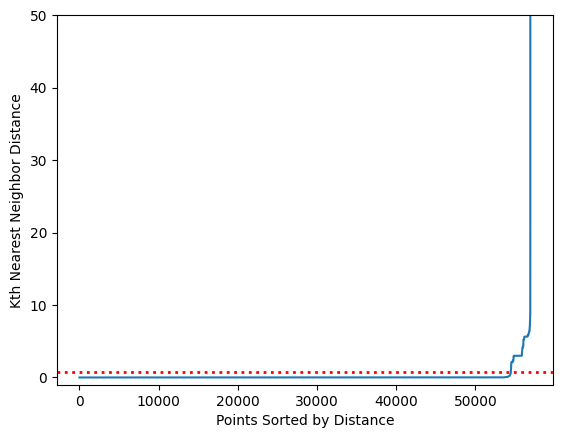

In [13]:
# 1. Set k to your min_samples value
k = min_samples

# 2. Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# 3. Sort distances by the k-th neighbor column (index k-1)
sorted_distances = np.sort(distances[:, k-1])

# 4. Plot to find the Epsilon elbow
plt.plot(sorted_distances)
plt.ylabel("Kth Nearest Neighbor Distance")
plt.xlabel("Points Sorted by Distance")
plt.ylim(bottom=-1, top=50)
plt.axhline(y=0.8, linestyle=':', color='red', linewidth=2)
None

In [35]:
eps = 0.001 # Based on the curve, 3 looks to be where the elbow is

In [38]:
X_scaled

array([[-0.01035443, -0.01035156, -0.16898352, ..., -0.18359868,
        -0.34782448, -0.38321441],
       [-0.01035933, -0.01035646, -0.16898352, ..., -0.18359868,
        -0.34782448, -0.38321441],
       [-0.01035926, -0.01035639, -0.16898352, ..., -0.18359868,
        -0.34782448, -0.38321441],
       ...,
       [-0.01028498, -0.01028211, -0.16898352, ..., -0.18359868,
        -0.34782448, -0.38321441],
       [-0.01031339, -0.01031051, -0.16898352, ..., -0.18359868,
        -0.34782448, -0.38321441],
       [-0.00973583, -0.00973295, -0.16898352, ..., -0.18359868,
        -0.34782448, -0.38321441]], shape=(56947, 38))

In [36]:
clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)

In [39]:
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 77
Estimated number of noise points: 5204


In [40]:
# Convert X to pandas df for easier aggregation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns).copy()

In [41]:
# Combine cluster labels and target variable into a single summary DataFrame
summary_df = pd.DataFrame({"cluster": labels, "target": y_resampled})

In [42]:
# --- 3. Aggregate Cluster Statistics ---
cluster_stats = (
    summary_df.groupby("cluster")
    .agg(
        cluster_size=("target", "count"),
        positive_count=("target", "sum"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

In [43]:
# Global metrics for context
global_pos_rate = y.mean()
print(f"Total Data Points: {len(X_scaled_df)}")
print(f"Global Positive Rate: {global_pos_rate:.4f}")
print(
    f"Number of Clusters (excluding noise): {len(set(labels)) - (1 if -1 in labels else 0)}"
)

Total Data Points: 56947
Global Positive Rate: 0.0010
Number of Clusters (excluding noise): 77


In [44]:
# --- 4. Identify Target-Rich Clusters ---
# Sort by highest concentration of your positive target class
high_purity_clusters = cluster_stats.sort_values(
    by="positive_rate", ascending=False
).head(10)
print("\n--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---")
print(high_purity_clusters.to_string(index=False))


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
      65           412             316       0.766990
      12          2278            1142       0.501317
       2           324             157       0.484568
      45           271             129       0.476015
      26          3459            1611       0.465742
      53           170              78       0.458824
      29           250             106       0.424000
      71           248             105       0.423387
       4           326             136       0.417178
      46           278             114       0.410072


In [45]:
# --- 5. Identify Popular Clusters ---
# Sort by size to find the largest groups (excluding noise cluster -1)
popular_clusters = (
    cluster_stats[cluster_stats["cluster"] != -1]
    .sort_values(by="cluster_size", ascending=False)
    .head(10)
)
print("\n--- TOP 10 LARGEST VALID CLUSTERS ---")
print(popular_clusters.to_string(index=False))


--- TOP 10 LARGEST VALID CLUSTERS ---
 cluster  cluster_size  positive_count  positive_rate
       9          6930             114       0.016450
       1          5158              90       0.017449
       6          4410              85       0.019274
      26          3459            1611       0.465742
      13          3243              52       0.016035
      12          2278            1142       0.501317
      11          1695              33       0.019469
      16          1653               0       0.000000
      22          1140              54       0.047368
      19          1088               0       0.000000


In [46]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = popular_clusters.iloc[0]["cluster"]

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 9.0 ---
                                    Cluster Mean   Global Mean  Difference
Amount_Received_USD                    -0.010218 -9.981811e-19   -0.010218
Amount_Paid_USD                        -0.010215  0.000000e+00   -0.010215
Receiving Currency_Bitcoin             -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real         -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar     -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                -0.553907  9.981811e-19   -0.553907
Receiving Currency_Mexican Peso        -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble               -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee               -0.196928  2.021317e-17   -0.196928
Receiving Currency_Saudi Riyal         -0.152121  6.388359e-17   -0.152121
Receiving Currency_Shekel              -0.191968  8.384721e-17   -0.191968
Receiving Currency_Swiss Franc         -0.220439 -7

In [47]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 9.0 ---
|--- Payment Format_Cheque <= 0.33
|   |--- class: 0
|--- Payment Format_Cheque >  0.33
|   |--- Payment Currency_US Dollar <= 0.27
|   |   |--- class: 0
|   |--- Payment Currency_US Dollar >  0.27
|   |   |--- Amount_Paid_USD <= -0.01
|   |   |   |--- class: 1
|   |   |--- Amount_Paid_USD >  -0.01
|   |   |   |--- class: 0



In [48]:
# Profiling the cluster with many positive class
target_cluster_id = 65

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 65 ---
                                    Cluster Mean   Global Mean  Difference
Amount_Received_USD                    -0.010239 -9.981811e-19   -0.010239
Amount_Paid_USD                        -0.010236  0.000000e+00   -0.010236
Receiving Currency_Bitcoin             -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real         -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar     -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                -0.553907  9.981811e-19   -0.553907
Receiving Currency_Mexican Peso        -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble               -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee               -0.196928  2.021317e-17   -0.196928
Receiving Currency_Saudi Riyal          6.573698  6.388359e-17    6.573698
Receiving Currency_Shekel              -0.191968  8.384721e-17   -0.191968
Receiving Currency_Swiss Franc         -0.220439 -7.

In [49]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 65 ---
|--- Payment Currency_Saudi Riyal <= 3.23
|   |--- class: 0
|--- Payment Currency_Saudi Riyal >  3.23
|   |--- Payment Format_Cheque <= 0.33
|   |   |--- Payment Format_Credit Card <= 0.62
|   |   |   |--- class: 1
|   |   |--- Payment Format_Credit Card >  0.62
|   |   |   |--- class: 0
|   |--- Payment Format_Cheque >  0.33
|   |   |--- class: 0



In [50]:
# Profiling the cluster with many positive class
target_cluster_id = 12

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 12 ---
                                    Cluster Mean   Global Mean  Difference
Amount_Received_USD                    -0.010266 -9.981811e-19   -0.010266
Amount_Paid_USD                        -0.010263  0.000000e+00   -0.010263
Receiving Currency_Bitcoin             -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real         -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar     -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                 1.805356  9.981811e-19    1.805356
Receiving Currency_Mexican Peso        -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble               -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee               -0.196928  2.021317e-17   -0.196928
Receiving Currency_Saudi Riyal         -0.152121  6.388359e-17   -0.152121
Receiving Currency_Shekel              -0.191968  8.384721e-17   -0.191968
Receiving Currency_Swiss Franc         -0.220439 -7.

In [55]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 12 ---
|--- Payment Currency_Euro <= 0.63
|   |--- class: 0
|--- Payment Currency_Euro >  0.63
|   |--- Payment Format_Cheque <= 0.33
|   |   |--- Payment Format_Credit Card <= 0.62
|   |   |   |--- Bank_Same <= 1.11
|   |   |   |   |--- Payment Format_Cash <= 1.45
|   |   |   |   |   |--- Payment Format_Wire <= 2.63
|   |   |   |   |   |   |--- Amount_Paid_USD <= -0.01
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Amount_Paid_USD >  -0.01
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Payment Format_Wire >  2.63
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Payment Format_Cash >  1.45
|   |   |   |   |   |--- class: 0
|   |   |   |--- Bank_Same >  1.11
|   |   |   |   |--- class: 0
|   |   |--- Payment Format_Credit Card >  0.62
|   |   |   |--- class: 0
|   |--- Payment Format_Cheque >  0.33
|   |   |--- class: 0



In [56]:
# Profiling the cluster with many positive class
target_cluster_id = 26

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 26 ---
                                    Cluster Mean   Global Mean  Difference
Amount_Received_USD                    -0.010251 -9.981811e-19   -0.010251
Amount_Paid_USD                        -0.010248  0.000000e+00   -0.010248
Receiving Currency_Bitcoin             -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real         -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar     -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                -0.553907  9.981811e-19   -0.553907
Receiving Currency_Mexican Peso        -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble               -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee               -0.196928  2.021317e-17   -0.196928
Receiving Currency_Saudi Riyal         -0.152121  6.388359e-17   -0.152121
Receiving Currency_Shekel              -0.191968  8.384721e-17   -0.191968
Receiving Currency_Swiss Franc         -0.220439 -7.

In [57]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 26 ---
|--- Receiving Currency_US Dollar <= 0.28
|   |--- class: 0
|--- Receiving Currency_US Dollar >  0.28
|   |--- Payment Format_Cheque <= 0.33
|   |   |--- Payment Format_Credit Card <= 0.62
|   |   |   |--- Bank_Same <= 1.11
|   |   |   |   |--- Payment Format_Cash <= 1.45
|   |   |   |   |   |--- Payment Format_Wire <= 2.63
|   |   |   |   |   |   |--- Amount_Paid_USD <= -0.01
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Amount_Paid_USD >  -0.01
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Payment Format_Wire >  2.63
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Payment Format_Cash >  1.45
|   |   |   |   |   |--- class: 0
|   |   |   |--- Bank_Same >  1.11
|   |   |   |   |--- class: 0
|   |   |--- Payment Format_Credit Card >  0.62
|   |   |   |--- class: 0
|   |--- Payment Format_Cheque >  0.33
|   |   |--- class: 0



## PPP

### Import Dataset

In [63]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ppp_cleaned.csv')
df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,0.0,48.0,2.0,24,769358.78,769358.78,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12409.01,0,1588291200,1605830400,1608249600
1,0.0,48.0,2.0,24,736927.79,736927.79,11.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10094.90,0,1588291200,1628726400,1632787200
2,0.0,48.0,2.0,24,691355.00,691355.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9218.07,0,1588291200,1612915200,1615939200
3,0.0,48.0,2.0,24,499871.00,499871.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,23803.38,0,1588291200,1631232000,1634342400
4,0.0,48.0,2.0,24,367437.00,367437.00,37.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,14697.48,0,1588291200,1617840000,1629158400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,0.0,56.0,2.0,24,150000.00,150000.00,54.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10000.00,0,1585872000,1607472000,1610496000
968528,0.0,56.0,2.0,24,150000.00,150000.00,31.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3452.38,0,1586822400,1604361600,1607385600
968529,1.0,56.0,2.0,60,150000.00,150000.00,54.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29999.40,0,1613088000,1629158400,1631664000
968530,0.0,56.0,2.0,60,150000.00,150000.00,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,21428.57,0,1586908800,1645574400,1646697600


In [64]:
df.dropna(inplace=True)

In [65]:
X = df.drop(columns='Fraud')
y = df['Fraud']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 968433, 1: 95})
Resampled dataset shape: Counter({0: 9500, 1: 95})


### Scaling

In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### DBScan

In [70]:
min_samples = 2 * len(X.columns) # 2*D to avoid clustering marking sparse regions as valid clusters. With a value of 3 I found 1800 clusters
min_samples

82

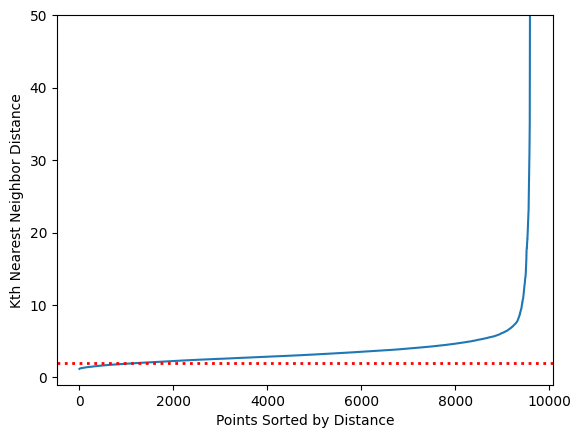

In [74]:
# 1. Set k to your min_samples value
k = min_samples

# 2. Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# 3. Sort distances by the k-th neighbor column (index k-1)
sorted_distances = np.sort(distances[:, k-1])

# 4. Plot to find the Epsilon elbow
plt.plot(sorted_distances)
plt.ylabel("Kth Nearest Neighbor Distance")
plt.xlabel("Points Sorted by Distance")
plt.ylim(bottom=-1, top=50)
plt.axhline(y=2, linestyle=':', color='red', linewidth=2)
None

In [128]:
eps = 4.0

In [129]:
clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)

In [130]:
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 1112


In [131]:
# Convert X to pandas df for easier aggregation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns).copy()

In [132]:
# Combine cluster labels and target variable into a single summary DataFrame
summary_df = pd.DataFrame({"cluster": labels, "target": y_resampled})

In [133]:
# --- 3. Aggregate Cluster Statistics ---
cluster_stats = (
    summary_df.groupby("cluster")
    .agg(
        cluster_size=("target", "count"),
        positive_count=("target", "sum"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

In [134]:
# Global metrics for context
global_pos_rate = y.mean()
print(f"Total Data Points: {len(X_scaled_df)}")
print(f"Global Positive Rate: {global_pos_rate:.4f}")
print(
    f"Number of Clusters (excluding noise): {len(set(labels)) - (1 if -1 in labels else 0)}"
)

Total Data Points: 9595
Global Positive Rate: 0.0001
Number of Clusters (excluding noise): 3


In [135]:
# --- 4. Identify Target-Rich Clusters ---
# Sort by highest concentration of your positive target class
high_purity_clusters = cluster_stats.sort_values(
    by="positive_rate", ascending=False
).head(10)
print("\n--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---")
print(high_purity_clusters.to_string(index=False))


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
       1           784              60       0.076531
      -1          1112              28       0.025180
       0          7335               7       0.000954
       2           364               0       0.000000


In [136]:
# --- 5. Identify Popular Clusters ---
# Sort by size to find the largest groups (excluding noise cluster -1)
popular_clusters = (
    cluster_stats[cluster_stats["cluster"] != -1]
    .sort_values(by="cluster_size", ascending=False)
    .head(10)
)
print("\n--- TOP 10 LARGEST VALID CLUSTERS ---")
print(popular_clusters.to_string(index=False))


--- TOP 10 LARGEST VALID CLUSTERS ---
 cluster  cluster_size  positive_count  positive_rate
       0          7335               7       0.000954
       1           784              60       0.076531
       2           364               0       0.000000


In [137]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = popular_clusters.iloc[0]["cluster"]

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 0.0 ---
                               Cluster Mean   Global Mean  Difference
ProcessingMethod                  -0.024540 -7.183183e-17   -0.024540
BorrowerState                      0.011793 -8.886413e-18    0.011793
LoanStatus                         0.283552 -5.331848e-17    0.283552
Term                              -0.039632  1.199666e-16   -0.039632
InitialApprovalAmount             -0.139838 -9.923161e-17   -0.139838
CurrentApprovalAmount             -0.139535 -1.658797e-16   -0.139535
ServicingLenderState              -0.001833 -4.146993e-17   -0.001833
RuralUrbanIndicator               -0.011414  1.077478e-16   -0.011414
HubzoneIndicator                  -0.027579 -4.739420e-17   -0.027579
LMIIndicator                      -0.028030 -1.999443e-17   -0.028030
BusinessAgeDescription            -0.003442 -1.303341e-16   -0.003442
ProjectState                       0.011793 -8.886413e-18    0.011793
JobsReported                      -0.1452

In [138]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 0.0 ---
|--- ForgivenPercentage <= -2.48
|   |--- ForgivenessDate_int <= 0.35
|   |   |--- LoanStatusDate_int <= 0.15
|   |   |   |--- class: 0
|   |   |--- LoanStatusDate_int >  0.15
|   |   |   |--- class: 0
|   |--- ForgivenessDate_int >  0.35
|   |   |--- class: 1
|--- ForgivenPercentage >  -2.48
|   |--- NonProfit <= 1.84
|   |   |--- PAYROLL_PROCEED_pct <= -1.59
|   |   |   |--- class: 0
|   |   |--- PAYROLL_PROCEED_pct >  -1.59
|   |   |   |--- class: 1
|   |--- NonProfit >  1.84
|   |   |--- class: 0



In [139]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = 1

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 1 ---
                               Cluster Mean   Global Mean  Difference
ProcessingMethod                   0.933529 -7.183183e-17    0.933529
BorrowerState                     -0.091943 -8.886413e-18   -0.091943
LoanStatus                        -2.437755 -5.331848e-17   -2.437755
Term                               0.992664  1.199666e-16    0.992664
InitialApprovalAmount             -0.232948 -9.923161e-17   -0.232948
CurrentApprovalAmount             -0.233551 -1.658797e-16   -0.233551
ServicingLenderState               0.052674 -4.146993e-17    0.052674
RuralUrbanIndicator                0.162449  1.077478e-16    0.162449
HubzoneIndicator                   0.034576 -4.739420e-17    0.034576
LMIIndicator                      -0.022827 -1.999443e-17   -0.022827
BusinessAgeDescription            -0.185984 -1.303341e-16   -0.185984
ProjectState                      -0.091943 -8.886413e-18   -0.091943
JobsReported                      -0.244255

In [143]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 1 ---
|--- ForgivenessAmount <= -0.64
|   |--- TOTAL_PROCEED <= 0.64
|   |   |--- NonProfit <= 1.84
|   |   |   |--- PAYROLL_PROCEED_pct <= -0.45
|   |   |   |   |--- TOTAL_PROCEED <= -0.49
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- TOTAL_PROCEED >  -0.49
|   |   |   |   |   |--- class: 0
|   |   |   |--- PAYROLL_PROCEED_pct >  -0.45
|   |   |   |   |--- LoanStatus <= -1.03
|   |   |   |   |   |--- PROCEED_Per_Job <= 2.96
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- PROCEED_Per_Job >  2.96
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- LoanStatus >  -1.03
|   |   |   |   |   |--- DateApproved_int <= 1.46
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- DateApproved_int >  1.46
|   |   |   |   |   |   |--- class: 1
|   |   |--- NonProfit >  1.84
|   |   |   |--- class: 0
|   |--- TOTAL_PROCEED >  0.64
|   |   |--- TOTAL_PROCEED <= 1.31
|   |   |   |--- ProcessingMethod <= 0.44
|   |   |   |